# User Churn Prediction System - Model Training

**Importing all required libraries**

In [2]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

**Loading the preprocessed data**

In [3]:
data_path = os.path.join(os.getcwd(), "data", "Telco-Customer-Churn.csv")
df = pd.read_csv(data_path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Data Processing**

In [5]:
le = LabelEncoder()
for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

**Divding Features and Target**

In [6]:
X = df.drop('Churn', axis=1)
y = df['Churn']

**Standardizing the numerical features**

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Splitting the data**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5634, 20), (1409, 20), (5634,), (1409,))

**Model selection and training**

Logistic Regression Accuracy: 0.8148
Random Forest Accuracy: 0.7970
Gradient Boosting Accuracy: 0.8084
Best Model: Logistic Regression with Accuracy = 0.8148

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.68      0.56      0.61       373

    accuracy                           0.81      1409
   macro avg       0.77      0.73      0.75      1409
weighted avg       0.81      0.81      0.81      1409



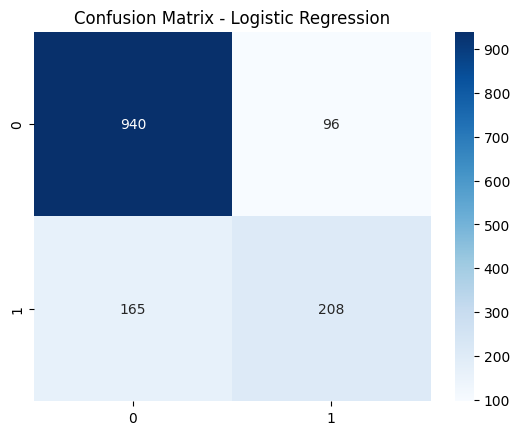

In [14]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

best_model = max(results, key=results.get)
print(f"Best Model: {best_model} with Accuracy = {results[best_model]:.4f}")

y_pred = models[best_model].predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - {best_model}")
plt.show()

* The Logistic Regression model achieved an accuracy of 81.48%, indicating solid performance in predicting customer churn.

* The model performs better at identifying non-churners (recall = 0.91) compared to churners (recall = 0.56), which suggests mild class imbalance  potential improvement using techniques like SMOTE or class weighting.

* Overall, the model provides reliable churn predictions and a good baseline for further optimization with ensemble models or hyperparameter tuning.
